In [1]:
import numpy as np
from dataclasses import dataclass, field

from shapely import affinity, box

from zeroheliumkit import Anchor, Structure, Layer, Rectangle, Square
from zeroheliumkit.src.settings import *
from zeroheliumkit.fem import *
from zeroheliumkit.src.plotting import ColorHandler

%matplotlib widget
%config InlineBackend.figure_format='retina'

In [2]:
# from codes.config import route_config, COBALT

plot_config = {"wafer":     LIGHTGRAY,
               "bottom":    YELLOW2,
               "top":       (BLUE, 0.8),
               "skeletone": WHITE,
               "anchors":   RED
}

In [3]:
@dataclass
class DomainGeometry:
    Lx: float=5.0
    Ly: float=5.0

@dataclass
class DotGeometry:
    l: float=3.0
    w: float=0.4
    g: float=0.4
    num: int=3
    channel_width: float=1.0

@dataclass
class ResonatorGeometry:
    w: float=0.7
    offset: float=1.0
    barrier: float=1.0

(-0.4, -1.5, 0.4, 1.5)


<Axes: >

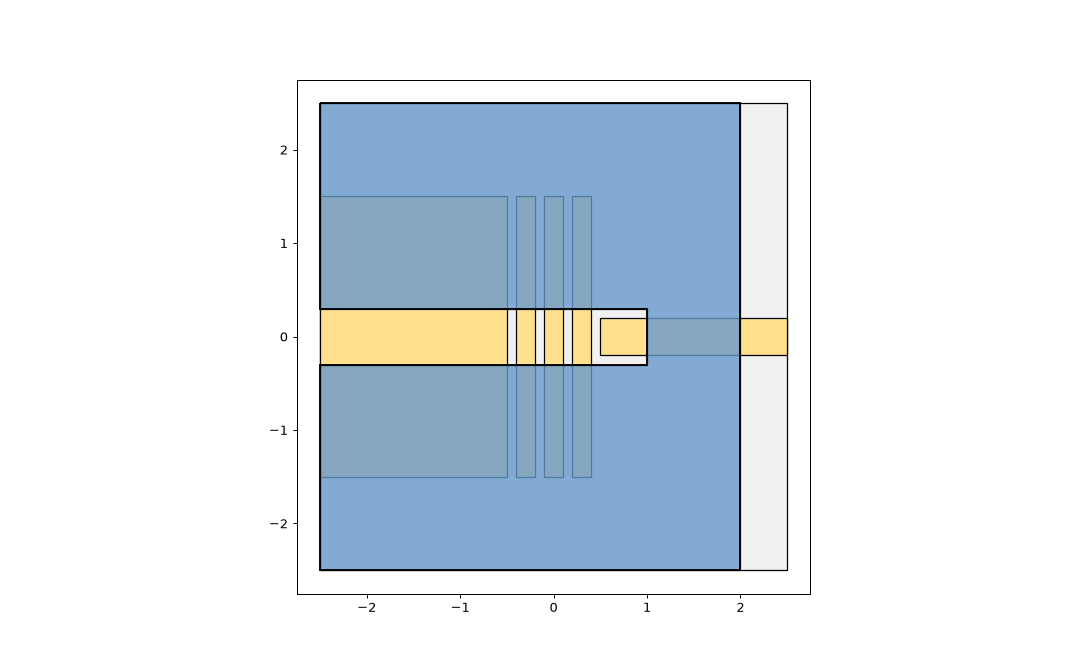

In [4]:
# build structure:
dot = DotGeometry(l=3.0, w=0.2, g=0.1, num=3, channel_width=0.6)
dom = DomainGeometry(Lx=5.0, Ly=5.0)
res = ResonatorGeometry(w=dot.channel_width - 0.2, offset=0.5, barrier=1.0)

###############
#### wafer ####
###############
l0 = Layer(name="wafer", polygons=Rectangle(dom.Lx, dom.Ly, (0,0)), color=LIGHTGRAY)

###############
### bottom ####
###############
l1 = Layer(name="bottom", color=YELLOW2)
for i in range(dot.num):
    leftmost_electrode_mid = -(dot.num - 1) * (dot.g + dot.w) / 2
    spacing = dot.g + dot.w
    l1.add(Rectangle(dot.w, dot.l, (leftmost_electrode_mid + i * spacing, 0)))

bbox = (leftmost_electrode_mid - dot.w/2, -dot.l/2, -leftmost_electrode_mid + dot.w/2, dot.l/2)
print(bbox)
l1.add(box(-dom.Lx/2, -dot.l/2, bbox[0] - dot.g, dot.l/2))
l1.add(box(bbox[2] + dot.g, -res.w/2, dom.Lx/2, res.w/2))

###############
##### top #####
###############
top_right_x = bbox[2] + dot.g + res.offset + res.barrier
l2 = Layer(name="top", color=(BLUE,0.8))
l2.add(box(-dom.Lx/2, -dom.Ly/2, top_right_x, dom.Ly/2))
l2.cut(box(-dom.Lx/2, -dot.channel_width/2, top_right_x - res.barrier, dot.channel_width/2))

# assemble structure
s = Structure()
s.add(l0)
s.add(l1)
s.add(l2)
s.colors = ColorHandler(plot_config)

s.quickplot(show_idx=False)

In [5]:
import os
from zeroheliumkit.fem import *

In [6]:
d_wafer     = 5
d_metal1    = 0.04
d_diel      = 0.02
d_metal2    = 0.2
d_vac       = 5

d_He = d_metal1 + d_diel + d_metal2
print(d_He)

save_dir = "test_adapt_coarse/"
os.makedirs(save_dir + "geo/", exist_ok=True)

msh_filename = 'dot'
s.export_pickle(save_dir + "geo/" + msh_filename)

0.26
Geometries saved successfully.


In [126]:
vols = {
    "wafer":        ExtrudeSettings(s.wafer.polygons, -d_wafer, d_wafer, "DIELECTRIC"),
    "Nb":           ExtrudeSettings(s.bottom.polygons, 0, d_metal1, "METAL"),
    "dielectric":   ExtrudeSettings(s.top.polygons, 0, d_metal1 + d_diel, "DIELECTRIC", ("Nb",)),
    "TaWSi":        ExtrudeSettings(s.top.polygons, d_metal1 + d_diel, d_metal2, "METAL"),
    "helium":       ExtrudeSettings(s.wafer.polygons, 0, d_He, "HELIUM", ("Nb", "dielectric", "TaWSi")),
    "vacuum":       ExtrudeSettings(s.wafer.polygons, d_He, d_vac, "VACUUM")
}

pecs = {
    "ch":   PECSettings(s.bottom.polygons, [0], volume=vols["Nb"]),
    "a":    PECSettings(s.bottom.polygons, [1], volume=vols["Nb"]),
    "b":    PECSettings(s.bottom.polygons, [2], volume=vols["Nb"]),
    "c":    PECSettings(s.bottom.polygons, [3], volume=vols["Nb"]),
    "res":  PECSettings(s.bottom.polygons, [4], volume=vols["Nb"]),
    "top":  PECSettings(s.top.polygons, [0], volume=vols["TaWSi"])
}

mesh = MeshSettings(
    dim = 3,
    fields = {
        "Box": [
            #BoxFieldMeshSettings(Thickness=2, VIn=0.03, VOut=2, box=[-1.2, 1.2, -1, 1, -0.2, 0.5]),
            #BoxFieldMeshSettings(Thickness=4, VIn=0.15, VOut=2, box=[-5, 5, -1, 1, -1, 1])
        ],
    },
)

In [127]:
mshmkr = GMSHmaker(
    extrude = vols,
    surfaces = None,
    pecs = pecs,
    mesh = mesh,
    save = {"dir": save_dir, "filename": msh_filename},
    open_gmsh = True,
    debug_mode = False
)

on 0: mesh is constructed                                                       
on 0: mesh saved                                                                
Gmsh generation  |███| 1/1 [100%] in 0.1s (13.45/s)                             


In [128]:
from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, FreeFEM

In [7]:
var_eps = {
        'DIELECTRIC': 11.0,
        'METAL': 1.0,
        'HELIUM': 1.057,
        'VACUUM': 1.0,
}

In [130]:
# use the mesh adaptation config to create msh_refinements
#from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, MeshAdaptationConfig

# for test_no_adapt:
ffc = FFconfigurator(config_file = save_dir + "dot.yaml",
                     dielectric_constants = var_eps,
                     ff_polynomial = 2,
                     extract_opt = [ExtractConfig("result1", 'phi', 'xy', (-2.5,1.5,201), (-1,1,101), round(d_He,3)),
                                     ExtractConfig("result2", 'phi', 'xy', (-1.5,1,251), (-0.6,0.6,151), [round(d_He,3), round(d_He + 0.03,3)]),
                                    ExtractConfig("result3", 'Ez', 'xy', (-1.5,1,251), (-0.6,0.6,151), round(d_He,3)),
                                   ],
                     msh_refinements = None
                     )

In [ ]:
from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, MeshAdaptationConfig

# for test_adapt:
ffc = FFconfigurator(config_file = save_dir + "dot.yaml",
                     dielectric_constants = var_eps,
                     ff_polynomial = 2,
                     extract_opt = [ExtractConfig("result1", 'phi', 'xy', (-2.5,1.5,201), (-1,1,101), round(d_He,3)),
                                   ],
                     msh_refinements = None,
                     adaptation_config = MeshAdaptationConfig(
                         mesh_adaptation = True,
                         anisotropic_adaptation = False,
                         n_adapt = 3, #change it to a function from 1, to 10
                         err_target = 0.01
                     )
                     )

In [ ]:
# for the loop:

import os
import shutil
import yaml
from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, MeshAdaptationConfig, FreeFEM

for n in range(1, 11):
    save_dir_n = f"test_adapt_n{n}/"
    os.makedirs(save_dir_n + "geo/", exist_ok=True)
    shutil.copy("test_adapt_coarse/geo/dot.msh", save_dir_n + "geo/dot.msh")
    shutil.copy("test_adapt_coarse/geo/dot.pickle", save_dir_n + "geo/dot.pickle")
    
    with open("test_adapt_coarse/dot.yaml", "r") as f:
        base_yaml = yaml.safe_load(f)
    base_yaml["savedir"] = save_dir_n
    base_yaml["meshfile"] = save_dir_n + "geo/dot.msh"
    with open(save_dir_n + "dot.yaml", "w") as f:
        yaml.safe_dump(base_yaml, f)
    
    ffc = FFconfigurator(
        config_file = save_dir_n + "dot.yaml",
        dielectric_constants = var_eps,
        ff_polynomial = 2,
        extract_opt = [ExtractConfig("result1", 'phi', 'xy', (-2.5,1.5,201), (-1,1,101), round(d_He,3))],
        msh_refinements = None,
        adaptation_config = MeshAdaptationConfig(
            mesh_adaptation = True,
            anisotropic_adaptation = False,
            n_adapt = n,
            err_target = 0.01
        ))
    
    pyff = FreeFEM(save_dir_n + "dot.yaml")
    await pyff.run(cores=6, print_log=False, remove=True)
    print(f"Done n_adapt={n}")

In [131]:
pyff = FreeFEM(config_file = save_dir + "dot.yaml")

In [114]:
await pyff.run(cores=6, print_log=False, remove=True)

HTML(value='<b>⏳ Running:</b> test_adapt_coarse/edp/ff_ch.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> test_adapt_coarse/edp/ff_a.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> test_adapt_coarse/edp/ff_b.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> test_adapt_coarse/edp/ff_c.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> test_adapt_coarse/edp/ff_res.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> test_adapt_coarse/edp/ff_top.edp', layout=Layout(margin='4px 0'))

In [115]:
from zeroheliumkit.fem.fieldreader import FreeFemResultParser, FieldAnalyzer
from zeroheliumkit.src.settings import BLACK, WHITE

In [116]:
ffparser = FreeFemResultParser(save_dir + "metadata.yaml", show=True)

                result1
--------------  -------------
Quantity        phi
Plane           xy
X Min           -2.5
X Max           1.5
X Num           201
Y Min           -1
Y Max           1
Y Num           101
Slices          1
Slice Values    [0.26]
Curved Surface  False
Schema          (1, 101, 201)
Control Electrodes: ['ch', 'a', 'b', 'c', 'res', 'top']


In [117]:
ffparser.get_capacitance_matrix()

[[-2817.45, 25.2591, 4.60109, 2.71412, 1.74349, 2801.4],
 [26.3435, -379.679, 20.6207, 2.20743, 0.550161, 346.178],
 [5.16537, 20.2433, -379.283, 20.6504, 0.975496, 348.083],
 [3.10652, 2.16084, 20.705, -377.281, 4.18674, 364.572],
 [1.98515, 0.544581, 0.975655, 4.29729, -282.544, 284.17],
 [2780.68, 329.653, 331.971, 345.666, 274.569, -4143.58]]